# Do the beaten-down commodities bounce back? 🛢️📉
### Commodity *value* — the textbook 'buy what's fallen' sort that the real tape flatly refuses to reward

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reversal: Refuted](https://img.shields.io/badge/Reversal-Refuted-8b949e?style=flat-square)

Here's the value investor's version of a commodity strategy: once a month, look at which commodities have **fallen the most over the last five years** (they're 'cheap') and which have **risen the most** (they're 'expensive'), then **buy the cheap third** and **short the expensive third**. Asness-Moskowitz-Pedersen (2013) showed this kind of long-horizon *reversal* paid across many markets. Does it work on stuff you could actually buy — a basket of commodity ETFs?

Short answer: **no.** It backtests at a flat **~+1%/yr**, no better than picking names out of a hat — and the 'cheap' commodities you bought actually *lagged*.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 13 single-commodity ETFs, 2012→2026, 163 monthly rebalances. The value signal reads the *raw price* (not total return), so five years of carry can't fake 'cheapness'. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from commodity_value import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICE = data.monthly_price()
    MRET = data.monthly_returns()
else:
    PRICE = MRET = None
print("real cache present:", HAVE_REAL, "| return panel:",
      (None if MRET is None else f"{MRET.shape[0]} months x {MRET.shape[1]} ETFs"))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'ls_start': '2012-12-31', 'ls_end': '2026-06-30', 'n_months': 163, 'n_etfs': 13, 'price_panel_months': 258, 'ret_panel_months': 220, 'mean_bps': 8.05, 'ann_pct': 0.97, 'hac_t': 0.166, 'hac_lags': 4, 'one_sample_t': 0.18, 'sharpe': 0.049, 'hit_pct': 54.0, 'turnover': 0.31, 'long_bps': -9.88, 'long_t': -0.32, 'short_bps': 17.93, 'short_t': 0.69, 'basket_ann': 1.29, 'placebo_seeds': 40, 'placebo_real_t': 0.166, 'placebo_mean_t': 0.222, 'placebo_sd_t': 1.109, 'placebo_mean_sharpe': 0.059, 'placebo_frac_ge2': 0.075, 'placebo_p': 0.525, 'era_split': '2019-07-01', 'early_n': 79, 'early_bps': 20.92, 'early_t': 0.33, 'early_sharpe': 0.14, 'late_n': 84, 'late_bps': -4.05, 'late_t': -0.06, 'late_sharpe': -0.02, 'diff_t': -0.28, 'timer5_gross': 0.97, 'timer5_net': 0.28, 'timer5_t': 0.05, 'timer5_sharpe': 0.01, 'timer10_gross': 0.97, 'timer10_net': 0.09, 'timer10_t': 0.02, 'timer10_sharpe': 0.0, 'syn_null_mean': -0.23, 'syn_null_sd': 0.97, 'syn_null_fire': 2, 'syn_planted_t': 6.41, 'syn_planted_bps': 257.15, 'syn_planted_sharpe': 1.98, 'fp': '0524773df8ac'}


real cache present: True | return panel: 220 months x 13 ETFs


## The answer first

| Question | Answer |
|---|---|
| Do cheap (fallen) commodities beat expensive (risen) ones? | **No — about +1%/yr** (Sharpe 0.05), a statistical zero (*t* = 0.17). |
| Is it at least better than a random pick? | **No.** A *random* ranking of the same commodities did just as well — marginally better, in fact. |
| Did the 'cheap' commodities you bought actually bounce? | **No — the opposite.** The cheap (long) leg *underperformed* the basket. The fallen ones kept lagging. |
| Do trading costs kill it? | **They don't need to.** There was nothing there to begin with — net is a rounding error at any cost. |

> A strategy that's real in the academic futures data but simply **isn't there** on a free, investable commodity-ETF basket — and even points the wrong way.

## 1 · The claim

> *"Commodities mean-revert over the long run. The ones that have crashed over the past five years are cheap and tend to recover; the ones that soared are expensive and tend to give it back. So rank them by how far they've fallen, buy the cheapest, short the priciest, and rebalance monthly."*

This is **value** — the same 'buy what's cheap' idea that's famous in stocks (cheap book-to-market beats expensive), here defined for commodities as a **5-year price reversal** (Asness-Moskowitz-Pedersen 2013). It's deliberately the **opposite horizon** to *momentum* (which buys the past-*year* winners) — the two are mirror images, which is exactly why the AMP paper pairs them.

## 2 · So what?

If real, this would be a clean, mechanical, once-every-few-years-of-signal rule with no forecasting — just rank on a 5-year price ratio and hold. It's one of the two legs (value + momentum) that underpin a huge swathe of 'liquid alternative' and managed-futures products. So it's worth checking whether the *value* leg — the buy-the-fallen half — actually delivers on instruments a normal investor can hold, or whether it's a spot-futures-only artefact that evaporates on real ETFs.

## 3 · How would we even know?

- **The sort.** Each month, rank the 13 ETFs by how far their price sits below (or above) where it was ~5 years ago; long the cheapest third, short the priciest third.
- **The *t*-test.** Is the average monthly profit big enough, relative to its wobble, to be real? (We use a stat that accounts for months bunching together.)
- **The luck check.** Rank the commodities *randomly* instead, dozens of times — does the real value ranking beat the coin-flips?
- **The direction check.** Did the *cheap* commodities you bought actually go up relative to the basket — or is the whole thing coming from the short side (or nowhere)?
- **The trade check.** Charge realistic costs and short-borrow — is there anything left?

## 4 · The teardown — let's actually look

**First, the equity curve.** One dollar in the long/short value book.

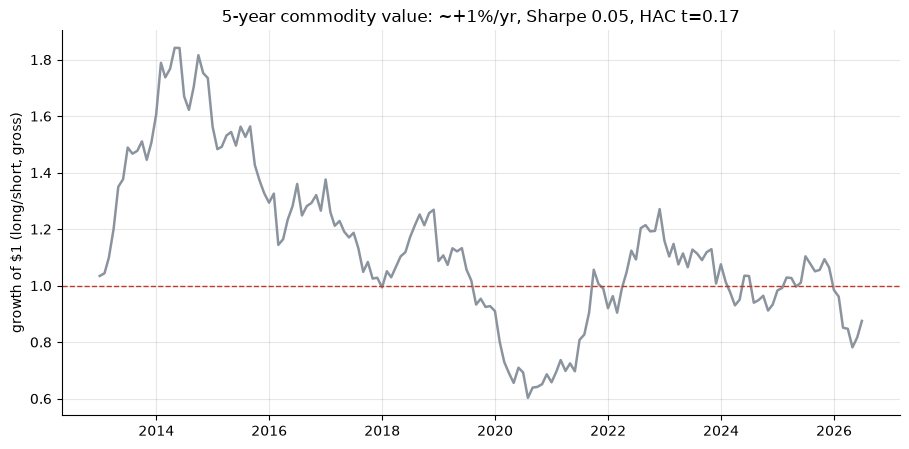

gross ~+0.97%/yr | Sharpe 0.05 | HAC t +0.17 (bar is 2)


In [2]:
if HAVE_REAL:
    rep = st.value_report(PRICE, MRET)
    ret = rep['ret']
    ann, shp, t = rep['ann_pct'], rep['sharpe'], rep['hac_t']
else:
    ret = None; ann, shp, t = R['ann_pct'], R['sharpe'], R['hac_t']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
if ret is not None:
    eq = (1 + ret).cumprod()
    ax.plot(eq.index, eq.values, color=GREY, lw=1.8)
    ax.axhline(1.0, ls='--', c=RED, lw=1)
ax.set_ylabel('growth of $1 (long/short, gross)')
ax.set_title(f'5-year commodity value: ~{ann:+.0f}%/yr, Sharpe {shp:.2f}, HAC t={t:.2f}')
plt.tight_layout(); plt.show()
print(f'gross ~{ann:+.2f}%/yr | Sharpe {shp:.2f} | HAC t {t:+.2f} (bar is 2)')

A flat, wandering line that ends roughly where it started — **~+1%/yr** at Sharpe **0.05**, HAC *t* = **0.17**. This is what *nothing* looks like. Compare it to the momentum sibling next door ([792](../../792-commodity-momentum/)), whose curve at least climbed before it faded.

**Is the value sort at least better than picking at random?** We rank the same commodities *randomly* 40 times and compare.

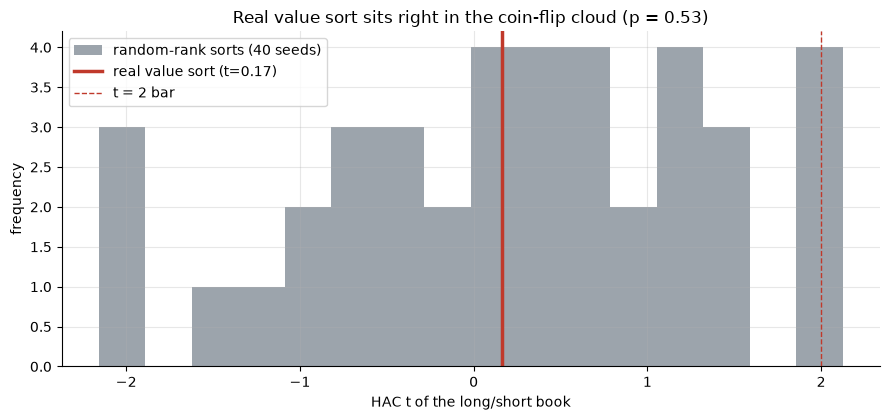

real t +0.17 vs random-rank mean +0.22; p = 0.53 -> indistinguishable from random


In [3]:
if HAVE_REAL:
    pl = st.random_placebo(PRICE, MRET)
    real_t, ts = pl['real_t'], pl['ts']
else:
    real_t = R['hac_t']
    ts = np.random.default_rng(793).normal(R['placebo_mean_t'], R['placebo_sd_t'], 40)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(ts, bins=16, color=GREY, alpha=.85, label='random-rank sorts (40 seeds)')
ax.axvline(real_t, c=RED, lw=2.5, label=f'real value sort (t={real_t:.2f})')
ax.axvline(2, ls='--', c=RED, lw=1, label='t = 2 bar')
ax.set_xlabel('HAC t of the long/short book'); ax.set_ylabel('frequency')
ax.set_title(f"Real value sort sits right in the coin-flip cloud (p = {R['placebo_p']:.2f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"real t {real_t:+.2f} vs random-rank mean {R['placebo_mean_t']:+.2f}; "
      f"p = {R['placebo_p']:.2f} -> indistinguishable from random")

The real value sort (red) sits **smack in the middle of the random-rank cloud** — **p = 0.53**, and the average coin-flip rank actually scored a hair *higher* (mean random *t* 0.22 vs real 0.17). The value ranking is doing nothing a blindfold couldn't.

**So where did the (tiny) P&L come from — did the cheap ones actually bounce?**

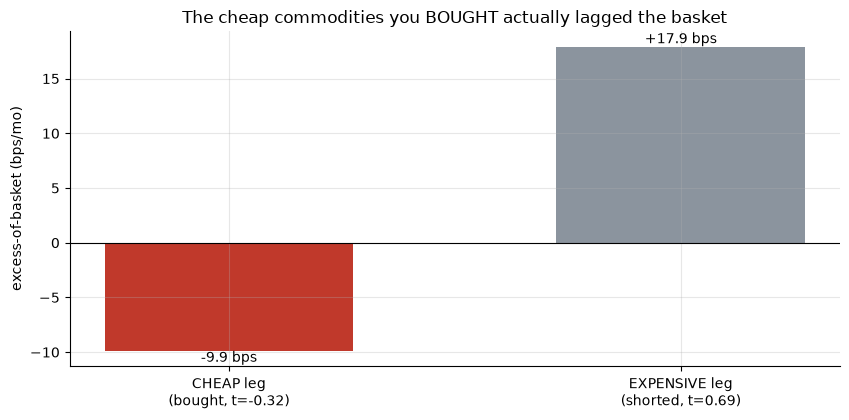

cheap (long) leg -9.88 bps (t=-0.32) | expensive (short) leg +17.93 bps (t=+0.69)


In [4]:
if HAVE_REAL:
    lg = st.long_short_legs(PRICE, MRET)
    lb, sb = lg['long_excess_bps'], lg['short_excess_bps']
    lt, stt = lg['long_t'], lg['short_t']
else:
    lb, sb = R['long_bps'], R['short_bps']
    lt, stt = R['long_t'], R['short_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['CHEAP leg\n(bought, t={:.2f})'.format(lt),'EXPENSIVE leg\n(shorted, t={:.2f})'.format(stt)],
       [lb, sb], color=[RED, GREY], width=.55)
for i,v in enumerate([lb, sb]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('excess-of-basket (bps/mo)')
ax.set_title('The cheap commodities you BOUGHT actually lagged the basket')
plt.tight_layout(); plt.show()
print(f'cheap (long) leg {lb:+.2f} bps (t={lt:+.2f}) | expensive (short) leg {sb:+.2f} bps (t={stt:+.2f})')

This is the punchline. The **cheap (long) leg you bought lost 10 bps/mo relative to the basket** (t = -0.32) — the fallen commodities kept lagging, the *opposite* of the value prediction. Whatever the L/S scraped together came only from the short (expensive) side (+18 bps/mo), and that's noise too (t = 0.69). **'Buy the beaten-down commodity' didn't just fail to pay — it pointed the wrong way.**

**Finally, the trade — is there anything to salvage after costs?**

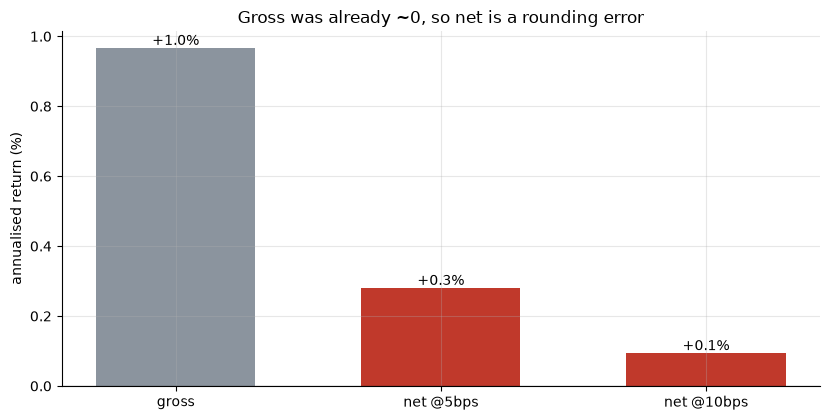

gross +1.0% -> net +0.3% (5bps) / +0.1% (10bps)


In [5]:
if HAVE_REAL:
    tm5 = st.costed_timer(PRICE, MRET, cost_bps=5.0)
    tm10 = st.costed_timer(PRICE, MRET, cost_bps=10.0)
    g, n5, n10 = tm5['gross_ann_pct'], tm5['net_ann_pct'], tm10['net_ann_pct']
else:
    g, n5, n10 = R['timer5_gross'], R['timer5_net'], R['timer10_net']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, RED, RED], width=.6)
for i,v in enumerate([g, n5, n10]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised return (%)')
ax.set_title('Gross was already ~0, so net is a rounding error')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}% -> net {n5:+.1f}% (5bps) / {n10:+.1f}% (10bps)')

Because a 5-year signal barely trades (turnover ~0.31× NAV), costs aren't even the point — the gross **+1%/yr** was already zero, so net is **+0.1%/yr** at 10 bps. There's simply **nothing to capture.**

## 5 · The verdict

- **Signal — None.** +1%/yr at Sharpe 0.05, HAC *t* = 0.17, indistinguishable from a random-rank sort (p = 0.53). Real in the AMP futures cross-section; **absent on this investable ETF tape.**
- **Tradability — Mirage.** Net ~0%/yr at any cost. Nothing to trade.
- **"Do the fallen ones bounce?" — Refuted.** The cheap (long) leg's excess return is *negative* (-10 bps/mo). The beaten-down commodities kept lagging.

## 6 · Going further 🚪

- **Why value 'should' work in commodities:** supply adjusts slowly, so a multi-year price crash eventually curbs production and the price mean-reverts. The theory is sound — but on 13 ETFs over 14 years it just doesn't show up.
- **Why the ETF proxy is hostile to it:** chronic-contango energy ETFs (USO, UNG) grind *down* for years from roll, so they look permanently 'cheap' for a mechanical reason — dirtying the very signal value depends on. AMP use spot prices to dodge exactly this.
- **Sibling studies:** [792-commodity-momentum](../../792-commodity-momentum/) runs the **opposite horizon** (past-year continuation) on the *same basket* (`WEAK`); [638-value-momentum-everywhere](../../638-value-momentum-everywhere/) blends value *and* momentum across four asset classes. See [docs/references.md](../docs/references.md) for the exact dedup.

*Think a broader basket or a spot-futures tape revives commodity value? Show a net, certifiable (HAC t ≥ 2) edge with a **positive cheap leg** — then we'll talk.*